# Where a mixture fit starts: every supported initializer at one budget

Fourteen starts of the joint count-pair emission mixture (issues #887, #891,
#901), and each of the eleven that read a generator again as the best of five
seedings (issue #905), and once more with every one of the five seedings
polished and the best fit kept (issue #912), each through the one seam, each polished by the same expectation-maximization
loop under the same budget, and read against the log-likelihood the generating
parameters reach on the same draw. No lattice and no chain: the emission model
alone, which is what a seeding of the coupled model's emission parameters sees.

Four terms the rest uses:

- A **`Budget`** (`opt.budget.Budget`) is a ceiling on the unit a method
  spends, held equal across methods so their results compare. One is held
  here (issue #898): every (start, seed) cell may spend
  `Budget(Cost.SECONDS, 120)`, two minutes of wall clock covering the start
  and its polish; a cell over it is refused.
- A **nat** is the unit of a log-likelihood difference in natural logarithms:
  a gap of `Δ = 1` nat is a likelihood ratio of `e ≈ 2.718`.
- The **loop** every start hands over to is the expectation-maximization
  iterations of `opt.emission_mixture.expectation_maximization`, one E step
  and one M step per pass, from equal weights, until the log-likelihood's
  relative change between two iterations is at most
  `search.mixture_starts.POLISH_TOLERANCE` = 1e-6 or the next iteration would
  pass what the start left of the 120 s.
- The **seam** is `opt.emission_mixture.CountPairSeeding`, which places a
  component on an observed pair. It is where every start ends, not a start of
  its own.

The instance is `emission_mixture/stress`: ten components of the joint
count-pair family, a negative-binomial total and a beta-binomial count of
successes out of it, over 3,000 pairs. It has no exact evidence, so the
reference is the **generating parameters' own value** on the draw, stated as
such. The count-pair mixture has no `theta` and is not an `Objective`, so the
four starts of `opt.initialize` and the three of `sample.initialize` run on a
surrogate, the Gaussian mixture over both channels, and none of the seven
applies to the count-pair likelihood itself; the Gaussian-mixture EM start
runs on the first channel alone, which is the one channel
`opt.mixture.expectation_maximization` fits.

In [1]:
import inspect
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Math, display
from snakes_and_ladders.cost import Cost
from snakes_and_ladders.opt.budget import Budget, compare
from snakes_and_ladders.opt.emission_mixture import CountPairSeeding
from snakes_and_ladders.opt.initialize import quantile_locations
from snakes_and_ladders.qa.starts import gap_panels, start_styles
from snakes_and_ladders.qa.starts_table import build_array, build_table
from snakes_and_ladders.qa.style import notebook_style
from snakes_and_ladders.sample import hmc
from snakes_and_ladders.search import mixture_starts
from snakes_and_ladders.search.mixture_starts import (
    BEST_OF,
    BEST_OF_EM_STARTS,
    BEST_OF_STARTS,
    DETERMINISTIC,
    POLISH_TOLERANCE,
    STARTS,
    StartRow,
    TimedStart,
    Trial,
    gap_band,
    instance_from,
)
from snakes_and_ladders.sim.emission_mixture import simulate_emission_mixture
from snakes_and_ladders.sim.fixtures import fixture

np.set_printoptions(precision=3, suppress=True)

## The instance, and the reference the starts are read against

`fixture` reads the declared file; nothing here builds an instance. The draw
is the fixture's own, under its declared seed, and the seam places a component
at the declared dispersion and concentration pooled over the components: one
pair carries no shape, so every start begins its components at those two.

In [2]:
# The declared instance: tests/regression/fixtures/emission_mixture/stress.yaml,
# its seed, its weights and its ten joint count-pair components.
declared = fixture("emission_mixture", "stress").params
# One draw of 3,000 pairs under the declared seed, with the generating
# component of each retained beside it.
dataset = simulate_emission_mixture(declared)
# The seam: a component on an observed pair, at the pooled dispersion and
# concentration, in the joint form the fixture declares.
at = CountPairSeeding(
    float(declared.components.total.dispersion.mean()),
    float(declared.components.concentration.mean()),
    joint=True,
)
# The draw, its truth and the seam as the one object every start reads.
instance = instance_from(dataset, at)
# The mixture log-likelihood at the generating parameters: the reference.
REFERENCE = instance.reference
print(
    "components",
    instance.n_components,
    "pairs",
    instance.n_samples,
    "seam dispersion",
    at.dispersion,
    "concentration",
    at.concentration,
)
print(f"the generating parameters reach {REFERENCE:.1f} nats")

components 10 pairs 3000 seam dispersion 60.0 concentration 15.0
the generating parameters reach -28268.1 nats


## The starts

Each start's description is the first paragraph of its own docstring in
`search.mixture_starts`, so the text cannot drift from the code, and its
settings are read off the objects the module builds for it. The order is the
table's.

In [3]:
def first_paragraph(obj: object) -> str:
    # The first paragraph of an object's docstring, on one line.
    return " ".join((inspect.getdoc(obj) or "").split("\n\n")[0].split())


# A generator for the builders below. It seeds only the torch streams they
# make; no setting printed here reads it.
probe = np.random.default_rng(0)
chain = mixture_starts.chain_initializer(probe)
annealing = mixture_starts.annealing_initializer(probe)
ladder = mixture_starts.tempering_initializer(probe)
restarts = mixture_starts.restart_initializer(probe)
tilt = mixture_starts.perturbation()
# The quantile levels `quantile_locations` takes, read off the function by
# asking it for the quantiles of the unit interval.
levels = quantile_locations(
    torch.linspace(0.0, 1.0, 1001, dtype=torch.float64), instance.n_components
)
schedule = annealing.schedule
SETTINGS = {
    "prior": "totals log-uniform over the observed range, fractions uniform on (0, 1)",
    "data": f"{instance.n_components} pairs, without replacement",
    "kmeans++": "squared Euclidean distance over the raw pair",
    "emission++": "the Bregman divergence of the seam's own family",
    "gaussian-em": (
        f"{mixture_starts.GAUSSIAN_EM_ITERATIONS} iterations from one k-means++ "
        f"start, a path entry every {mixture_starts.PATH_STRIDE}"
    ),
    "objective": "the surrogate's nominated point",
    "perturbed": f"tilt {tilt.magnitude:g} in unconstrained coordinates, alternating sign",
    "restart": (
        f"{restarts.n_starts} points at spread {restarts.scale:g} in unconstrained "
        f"coordinates, the best by surrogate value kept"
    ),
    "quantile": "levels " + ", ".join(f"{q:.2f}" for q in levels.tolist()),
    "burn-in": (
        f"{mixture_starts.BURN_IN_ITERATIONS} EM iterations on "
        f"{mixture_starts.BURN_IN_FRACTION:.0%} of the pairs"
    ),
    "hmc": (
        f"warm-up of {chain.adaptation.warmup} proposals to acceptance "
        f"{chain.adaptation.target_acceptance:g}, step jitter "
        f"{chain.adaptation.step_jitter:g}, from step {chain.step_size:g}; "
        f"{chain.n_steps} leapfrog steps a proposal, {chain.burn_in} draws "
        f"discarded after it, {chain.n_samples} kept"
    ),
    "anneal": (
        f"{type(schedule).__name__} from {schedule.start:g} to {schedule.end:g} "
        f"over {schedule.n_steps} proposals, step {annealing.step_size:g}, "
        f"{annealing.n_steps} leapfrog steps a proposal"
    ),
    "gibbs-anneal": (
        f"one heat-bath sweep over the assignments at each of "
        f"{', '.join(f'{x:.2f}' for x in mixture_starts.gibbs_schedule())}, "
        f"from the data draw, the components re-estimated at each sweep's "
        f"assignments"
    ),
    "tempering": (
        f"ladder {ladder.temperatures}, {ladder.n_rounds} rounds of one transition "
        f"per rung, step {ladder.step_size:g}, {ladder.n_steps} leapfrog steps; "
        f"exchange: {first_paragraph(hmc.parallel_tempering)}"
    ),
}
SINGLE = list(STARTS)
for name in SINGLE:
    print(f"{name:11s} {first_paragraph(STARTS[name])}")
    print(f"{'':11s}   {SETTINGS[name]}")
# The best-of group (issue #905): each stochastic start run BEST_OF times on
# the cell's generator, the seeding of highest log-likelihood handed over.
print()
print(first_paragraph(mixture_starts.BestOf))
print(", ".join(BEST_OF_STARTS))
# The polished best-of group (issue #912): the same five seedings, each
# polished by EM, the fit of highest log-likelihood kept.
print()
print(first_paragraph(mixture_starts.BestOf.polished))
print(", ".join(BEST_OF_EM_STARTS))
# The table's order: the single-seeding starts, then the two best-of groups.
ORDER = SINGLE + list(BEST_OF_STARTS) + list(BEST_OF_EM_STARTS)

prior       Components drawn from a prior over the observed range, reading no pair.
              totals log-uniform over the observed range, fractions uniform on (0, 1)
data        ``uniform_start``: components on pairs drawn uniformly without replacement.
              10 pairs, without replacement
kmeans++    ``kmeans_plus_plus`` on the raw pair, its centres handed to the seam.
              squared Euclidean distance over the raw pair
emission++  ``plus_plus_start``: D-squared sampling under the family's Bregman divergence.
              the Bregman divergence of the seam's own family
gaussian-em The Gaussian mixture fitted to the first channel from k-means++, its means the locations.
              500 iterations from one k-means++ start, a path entry every 25
objective   ``FromObjective``: the surrogate's own nominated point.
              the surrogate's nominated point
perturbed   ``Perturbed``: that point, tilted off a symmetry it may be stationary at.
              tilt 0.1 in

## Every start, once per seed, under one budget

The trials run through `opt.budget.compare`, which hands each (start, seed)
cell to `snakes_and_ladders.parallel` on a pool of four worker processes, one
per core of the host, each at one intra-op thread, each cell seeding its own
generator `default_rng([seed, 0])`, so a cell draws the same stream at every
worker count. Each cell is a `search.mixture_starts.TimedStart`: the start
runs inside a `track` block nested in the one the polish runs in, so every
sample it records carries its own time, and the handover is one sample of its
own. The one budget covers the whole cell: the polish is handed the seconds
the start left, and the spend `compare` checks is the cell's seconds.

**Five seeds, three groups.** A polish to the 1e-6 tolerance runs 40 to 350
EM iterations of about 0.012 s each on one core since the count M step is
compiled (issues #892, #918, #922), so a cell takes a few seconds. The eleven
stochastic starts at five seeds, the three deterministic ones once, and the
best-of group --- each stochastic start run five times on the cell's generator,
the seeding of highest log-likelihood at equal weights handed over, charged
all five seedings (`search.mixture_starts.BestOf`, issue #905) --- at five
seeds are 113 cells on four workers.

**A fourth group polishes every seeding.** `BestOf(select=Selection.POLISHED)`
polishes every one of its five seedings, each handed the seconds left over the
seedings left, and keeps the fit of highest log-likelihood (issue #912): five
polishes a cell where the best-of group runs one. At five seeds it is 55 more
cells, 168 in all, and the notebook's budget is 1,000 s.

In [4]:
#: The five seeds of every start that reads a generator.
TRIALS = [0, 1, 2, 3, 4]

#: Cells run at once, one worker process per core of the 4-core host.
WORKERS = 4

#: The one budget each (start, seed) cell runs under, start and polish.
BUDGET = Budget(Cost.SECONDS, 120)

GROUPS = {
    "stochastic": ([n for n in SINGLE if n not in DETERMINISTIC], TRIALS),
    "deterministic": ([n for n in SINGLE if n in DETERMINISTIC], [0]),
    f"best-of-{BEST_OF}": (list(BEST_OF_STARTS), TRIALS),
    f"best-of-{BEST_OF}+em": (list(BEST_OF_EM_STARTS), TRIALS),
}

load_before = os.getloadavg()
opened = time.perf_counter()
comparisons = {}
trials: dict[str, list[Trial]] = {}
for group, (names, seeds) in GROUPS.items():
    # Every (start, seed) cell of the group on the pool: its reached value,
    # its whole seconds, and the Trial it carries back.
    comparison = compare(
        {name: TimedStart(name) for name in names},
        [instance],
        BUDGET,
        seeds,
        workers=WORKERS,
        known=[-REFERENCE],
    )
    comparisons[group] = comparison
    # The outcomes are in start, instance, seed order: one block of seeds each.
    for row, name in enumerate(comparison.methods):
        block = comparison.outcomes[row * len(seeds) : (row + 1) * len(seeds)]
        trials[name] = [outcome.detail for outcome in block]
elapsed = time.perf_counter() - opened
load_after = os.getloadavg()

# One row per start, read against the reference, in the table's order.
rows = [StartRow.from_trials(name, trials[name], REFERENCE) for name in ORDER]
print(
    f"{sum(row.trials for row in rows)} fits of {len(rows)} starts, "
    f"each under {BUDGET.size} {BUDGET.unit}, polish tolerance "
    f"{POLISH_TOLERANCE:g}, on {WORKERS} workers"
)

168 fits of 36 starts, each under 120 seconds, polish tolerance 1e-06, on 4 workers


## What each start handed over

A row states, over its trials: the log-likelihood at the handover (seeded
value), its **gap**, the reference less the seeded value, in nats, the passes
the start itself charged, and the bytes of the fitted state. A negative gap is
a value that passed the generating parameters'. At more than one trial the gap
carries its sample standard deviation, `±`.

**Where the polish stops is the host's, so only the handover is compared.** A
polish stops at its tolerance or at the budget, whichever comes first. A cell
that stops at the tolerance ends at a value continuous in the seeds, but one
host can reach the tolerance inside 120 s where a slower one cannot, and then
the reached value is wherever the clock stopped it. So every reading after the
handover --- the reached value, its gap, the iterations and the stop --- is in
the `host-dependent` section below, with the recovery and the seconds.

**One handover is the host's too: the warmed-up Hamiltonian chain's.** Its
300 warm-up proposals and the draws after them amplify a last-bit difference
in a reduction, and the reduction's bits follow the code path MKL picks for the
CPU (issue #895): seed 0 hands over at -29,947.6 on the reference host's
default path and at -29,260.5 under `MKL_CBWR=AVX2`, while every other start
hands over the same value on both. So `hmc`'s seeded value is printed in the
`host-dependent` section and marked here.

In [5]:
COMPARED = (
    "start",
    "trials",
    "seeded value",
    "init. gap (nats)",
    "passes",
    "state bytes",
)
HOST = (
    "start",
    "init. gap (nats)",
    "reached value",
    "final gap (nats)",
    "iterations",
    "stopped at",
    "recovery",
    "mean relative error",
    "seconds",
    "seeding seconds",
)


def spread(values: tuple[float, ...], digits: int) -> str:
    # The mean, and the sample standard deviation beside it at more than one
    # trial.
    mean = f"{np.mean(values):.{digits}f}"
    if len(values) == 1:
        return mean
    return f"{mean} ± {np.std(values, ddof=1):.{digits}f}"


#: Starts whose handover follows the host's floating-point path (above), and
#: the polished best-of group, whose handover is chosen on where its polishes
#: stopped, a reading the section below holds as the host's.
HOST_HANDOVER = frozenset({"hmc", f"hmcx{BEST_OF}", *BEST_OF_EM_STARTS})


def cells(row: StartRow, *, compared: bool = False) -> dict[str, str]:
    # One row's columns, each a string; in the compared table a handover
    # that belongs to the host is named rather than printed.
    held = compared and row.start in HOST_HANDOVER
    return {
        "start": row.start,
        "trials": "deterministic"
        if row.deterministic
        else f"{row.trials} trial{'s' if row.trials > 1 else ''}",
        "seeded value": "host-dependent" if held else spread(row.seeded, 1),
        "init. gap (nats)": "host-dependent" if held else spread(row.seeded_gap, 1),
        "passes": f"{row.passes:.1f}",
        "state bytes": str(row.state_bytes),
        "reached value": spread(row.reached, 1),
        "final gap (nats)": spread(row.gap, 1),
        "iterations": spread(tuple(float(i) for i in row.iterations), 0),
        "stopped at": (
            f"tolerance {sum(row.converged)}, emptied {sum(row.emptied)}, "
            f"budget {row.trials - sum(row.converged) - sum(row.emptied)}"
        ),
        "recovery": spread(row.recovery, 3),
        "mean relative error": spread(row.mean_error, 3),
        "seconds": spread(row.seconds, 1),
        "seeding seconds": spread(row.seeding_seconds, 2),
    }


def table(columns: tuple[str, ...], *, compared: bool = False) -> str:
    # A markdown table of every row, in the order of ORDER.
    lines = ["| " + " | ".join(columns) + " |", "|" + "---|" * len(columns)]
    lines += [
        "| " + " | ".join(cells(row, compared=compared)[c] for c in columns) + " |"
        for row in rows
    ]
    return "\n".join(lines)


print(f"gaps are nats below the {REFERENCE:.1f} the generating parameters reach")
print()
print(table(COMPARED, compared=True))

gaps are nats below the -28268.1 the generating parameters reach

| start | trials | seeded value | init. gap (nats) | passes | state bytes |
|---|---|---|---|---|---|
| prior | 5 trials | -34906.0 ± 476.9 | 6638.0 ± 476.9 | 0.0 | 400 |
| data | 5 trials | -33726.3 ± 2537.6 | 5458.2 ± 2537.6 | 0.0 | 400 |
| kmeans++ | 5 trials | -31996.3 ± 1022.8 | 3728.2 ± 1022.8 | 1.0 | 400 |
| emission++ | 5 trials | -31226.5 ± 951.2 | 2958.4 ± 951.2 | 1.0 | 400 |
| gaussian-em | 5 trials | -30036.5 ± 402.5 | 1768.4 ± 402.5 | 500.0 | 400 |
| objective | deterministic | -30065.0 | 1797.0 | 0.0 | 400 |
| perturbed | deterministic | -30065.0 | 1797.0 | 0.0 | 400 |
| restart | 5 trials | -30096.7 ± 39.1 | 1828.7 ± 39.1 | 4.0 | 400 |
| quantile | deterministic | -30065.0 | 1797.0 | 0.0 | 400 |
| burn-in | 5 trials | -28813.0 ± 268.0 | 545.0 ± 268.0 | 0.6 | 400 |
| hmc | 5 trials | host-dependent | host-dependent | 5544.0 | 400 |
| anneal | 5 trials | -29996.8 ± 75.8 | 1728.7 ± 75.8 | 144.0 | 400 |
| gibb

## Where each polish stopped, what it recovered, and what it cost in seconds

The **reached value** and the **final gap** are read where the polish
stopped, and **stopped at** counts the trials that stopped at the tolerance, at an
emptied component --- one whose weight fell below one pair's share, a fit of
fewer components that the polish does not continue --- and at the budget. The **recovery** is the fraction of pairs the fit
assigns to their generating component, up to the best renaming of the
components; the **mean relative error** is the largest relative error left in
a component's first-channel mean over that renaming. Both are read through a
permutation match whose near-ties flip when a reduction is ordered
differently, so they are not reproducible text across hosts, and the
**seconds** are a wall clock. The cell is tagged `host-dependent`: the notebook
checker runs it and does not compare its text (`docs/nb/README.md`). Beneath
the table are `opt.budget.compare`'s own tables, hits of the reference and the
whole seconds of each cell against the 120 s, and the table of seconds and gap
per initializer that `qa.starts_table` builds, each time before its gap and
the rows from the lowest mean final gap: its LaTeX `tabular` and
caption, printed and not written, since `docs/tex/generated/` holds the
ledgers `infra/ledgers.sh` writes and no document cites this table yet, and
the same cells as the `array` the notebook renders.

In [6]:
print(
    f"host: {os.cpu_count()} cores, {WORKERS} workers; 1-minute load "
    f"{load_before[0]:.2f} before the trials and {load_after[0]:.2f} after; "
    f"the trials took {elapsed:.0f} s"
)
print()
print(table(HOST))
for group, comparison in comparisons.items():
    print()
    print(f"{group} starts, {len(GROUPS[group][1])} seed(s):")
    print(comparison.table())
print()
# The LaTeX tabular of gap and seconds per initializer, and its caption.
body, caption = build_table(
    rows,
    instance="the emission-mixture stress fixture",
    seconds=BUDGET.size,
    seeds=len(TRIALS),
)
print(body)
print()
print(caption)
# The same cells as an array, which MathJax renders in the notebook.
display(Math(build_array(rows)))

host: 4 cores, 4 workers; 1-minute load 4.55 before the trials and 3.81 after; the trials took 295 s

| start | init. gap (nats) | reached value | final gap (nats) | iterations | stopped at | recovery | mean relative error | seconds | seeding seconds |
|---|---|---|---|---|---|---|---|---|---|
| prior | 6638.0 ± 476.9 | -28319.1 ± 82.1 | 51.1 ± 82.1 | 199 ± 70 | tolerance 4, emptied 1, budget 0 | 0.421 ± 0.273 | 0.532 ± 0.308 | 1.8 ± 0.7 | 0.00 ± 0.00 |
| data | 5458.2 ± 2537.6 | -28303.3 ± 17.3 | 35.3 ± 17.3 | 116 ± 69 | tolerance 5, emptied 0, budget 0 | 0.536 ± 0.044 | 0.557 ± 0.074 | 1.1 ± 0.6 | 0.00 ± 0.00 |
| kmeans++ | 3728.2 ± 1022.8 | -28291.6 ± 17.5 | 23.6 ± 17.5 | 104 ± 53 | tolerance 5, emptied 0, budget 0 | 0.365 ± 0.014 | 2.249 ± 1.852 | 1.0 ± 0.5 | 0.00 ± 0.00 |
| emission++ | 2958.4 ± 951.2 | -28263.6 ± 18.6 | -4.5 ± 18.6 | 225 ± 105 | tolerance 5, emptied 0, budget 0 | 0.615 ± 0.222 | 0.629 ± 0.669 | 2.3 ± 1.0 | 0.19 ± 0.00 |
| gaussian-em | 1768.4 ± 402.5 | -28287.3 ±

<IPython.core.display.Math object>

## Where each start places its components, and where the fit leaves them

Two panels per start, seed 0: the components as seeded (left) and as fitted where
the polish stopped (right), each at its two channels' means, over the pairs in grey and
the generating components as crosses.

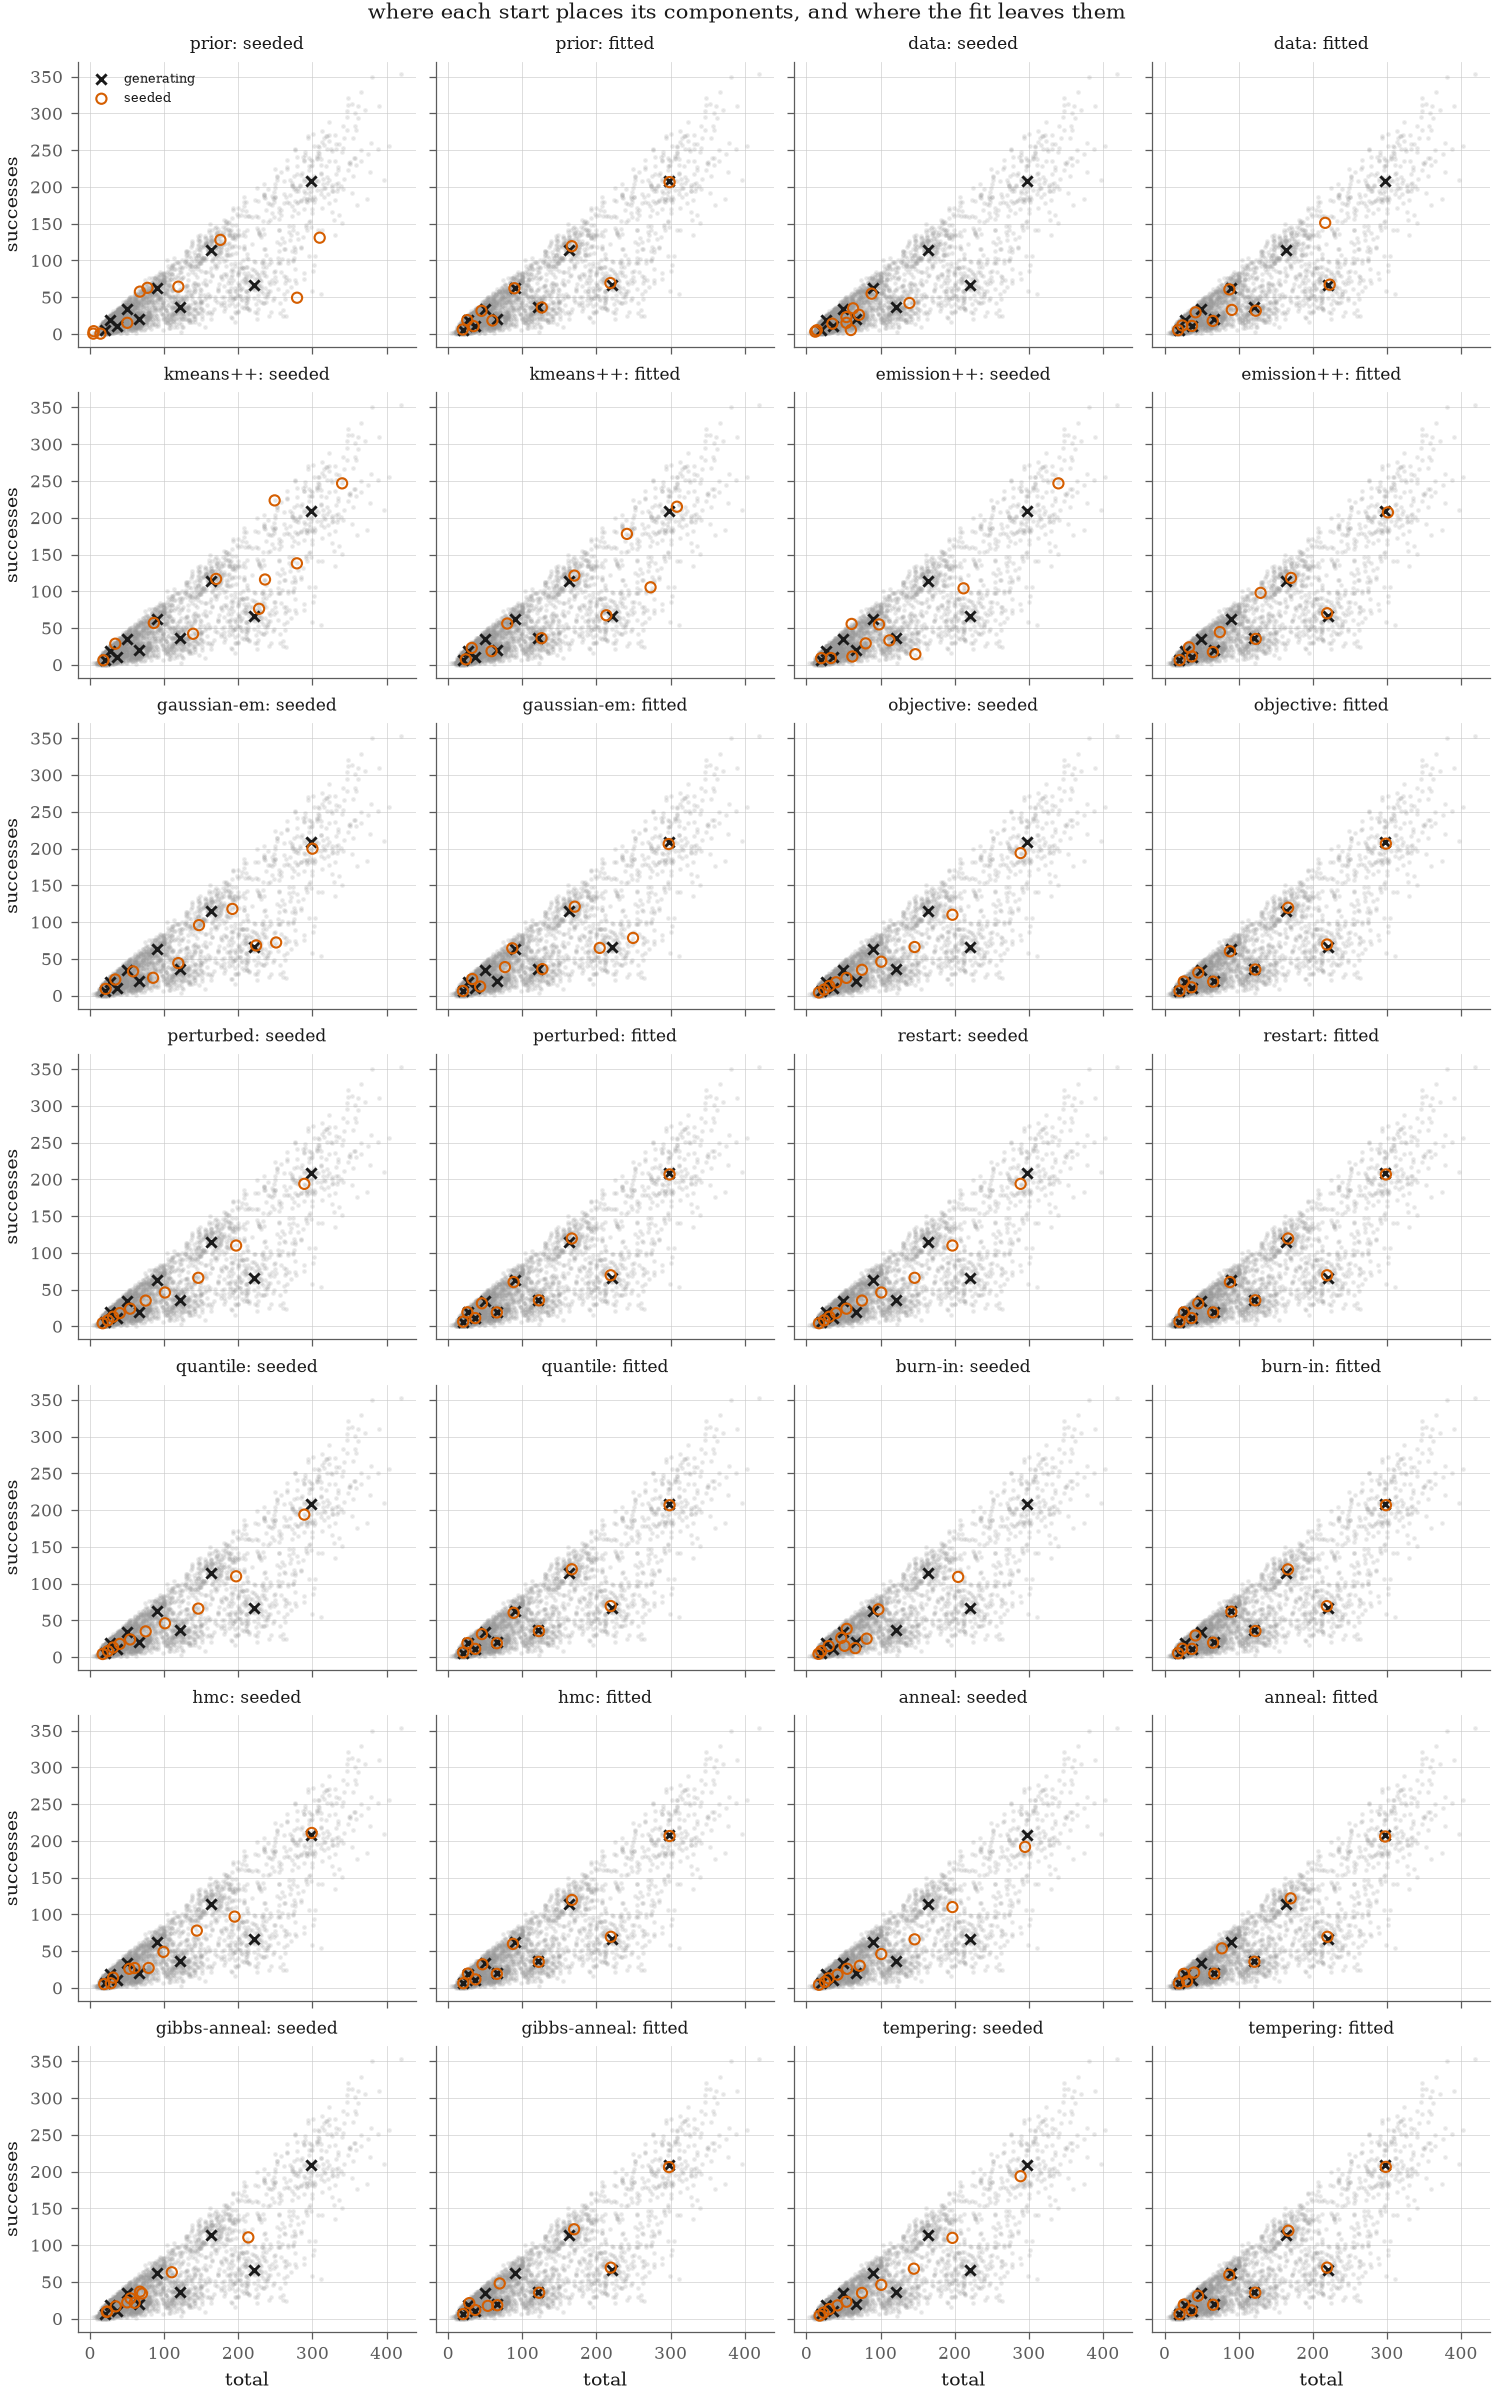

In [7]:
with notebook_style():
    figure, axes = plt.subplots(
        7, 4, figsize=(10.0, 16.0), sharex=True, sharey=True, constrained_layout=True
    )
    panels = axes.ravel()
    for index, name in enumerate(SINGLE):
        trial = trials[name][0]
        for side, (family, title) in enumerate(
            (
                (trial.seeded.components, "seeded"),
                (trial.polished.components, "fitted"),
            )
        ):
            axis = panels[2 * index + side]
            axis.scatter(
                instance.observations[:, 0],
                instance.observations[:, 1],
                s=2,
                alpha=0.15,
                color="0.6",
            )
            # Both channels' means: the first two columns of the family's
            # alignment key.
            generating = instance.truth.alignment_key()[:, :2].numpy()
            placed = family.alignment_key()[:, :2].numpy()
            axis.scatter(
                *generating.T, marker="x", s=24, color="0.1", label="generating"
            )
            axis.scatter(
                *placed.T,
                marker="o",
                s=24,
                facecolor="none",
                edgecolor="#D55E00",
                linewidth=1.0,
                label=title,
            )
            axis.set_title(f"{name}: {title}", fontsize=8)
    for axis in panels[2 * len(SINGLE) :]:
        axis.set_axis_off()
    for axis in axes[-1]:
        axis.set_xlabel("total")
    for axis in axes[:, 0]:
        axis.set_ylabel("successes")
    panels[0].legend(fontsize=6, loc="upper left")
    figure.suptitle(
        "where each start places its components, and where the fit leaves them",
        fontsize=10,
    )
    plt.show()

## Gap against runtime

Each start's gap below the generating parameters, in nats, against the wall
seconds from the start's first call: the mean over its trials of each trial's
gap held from one `track` sample to the next. Both axes are logarithmic, the
runtime from 0.01 s and the gap linear within a nat of zero so the fits that
pass the reference stay on it. Drawn are the starts whose mean final gap is at
most one nat --- within a nat of the generating parameters or past them ---
listed from the lowest mean final gap to the highest; the rest are read in the
tables above. The left panel is the starts at one seeding, the middle the
best-of group and the right the polished best-of group, each
best-of curve in its base start's colour; a polished best-of polishes inside
the start, so its curve steps from the scored seedings to the chosen fit at
the handover. `SHOW_BANDS = True` adds, at more than one trial, a band of one
sample standard deviation either side. A start that iterates --- the Gaussian
EM, the burn-in, the Hamiltonian chain --- draws its own iterations first, each
at the components it would hand over; the diamond is the handover at its mean
time; what follows is the EM polish, ending where the tolerance or the budget
stopped it. The annealing and tempering runs return their best point and not
the path to it, so their curves start at the handover. The figure is
`qa.starts.gap_panels`, the one `potts_starts` draws, each base start one of its
fourteen colours. The x axis is a wall clock, so the cell is tagged
`host-dependent`.

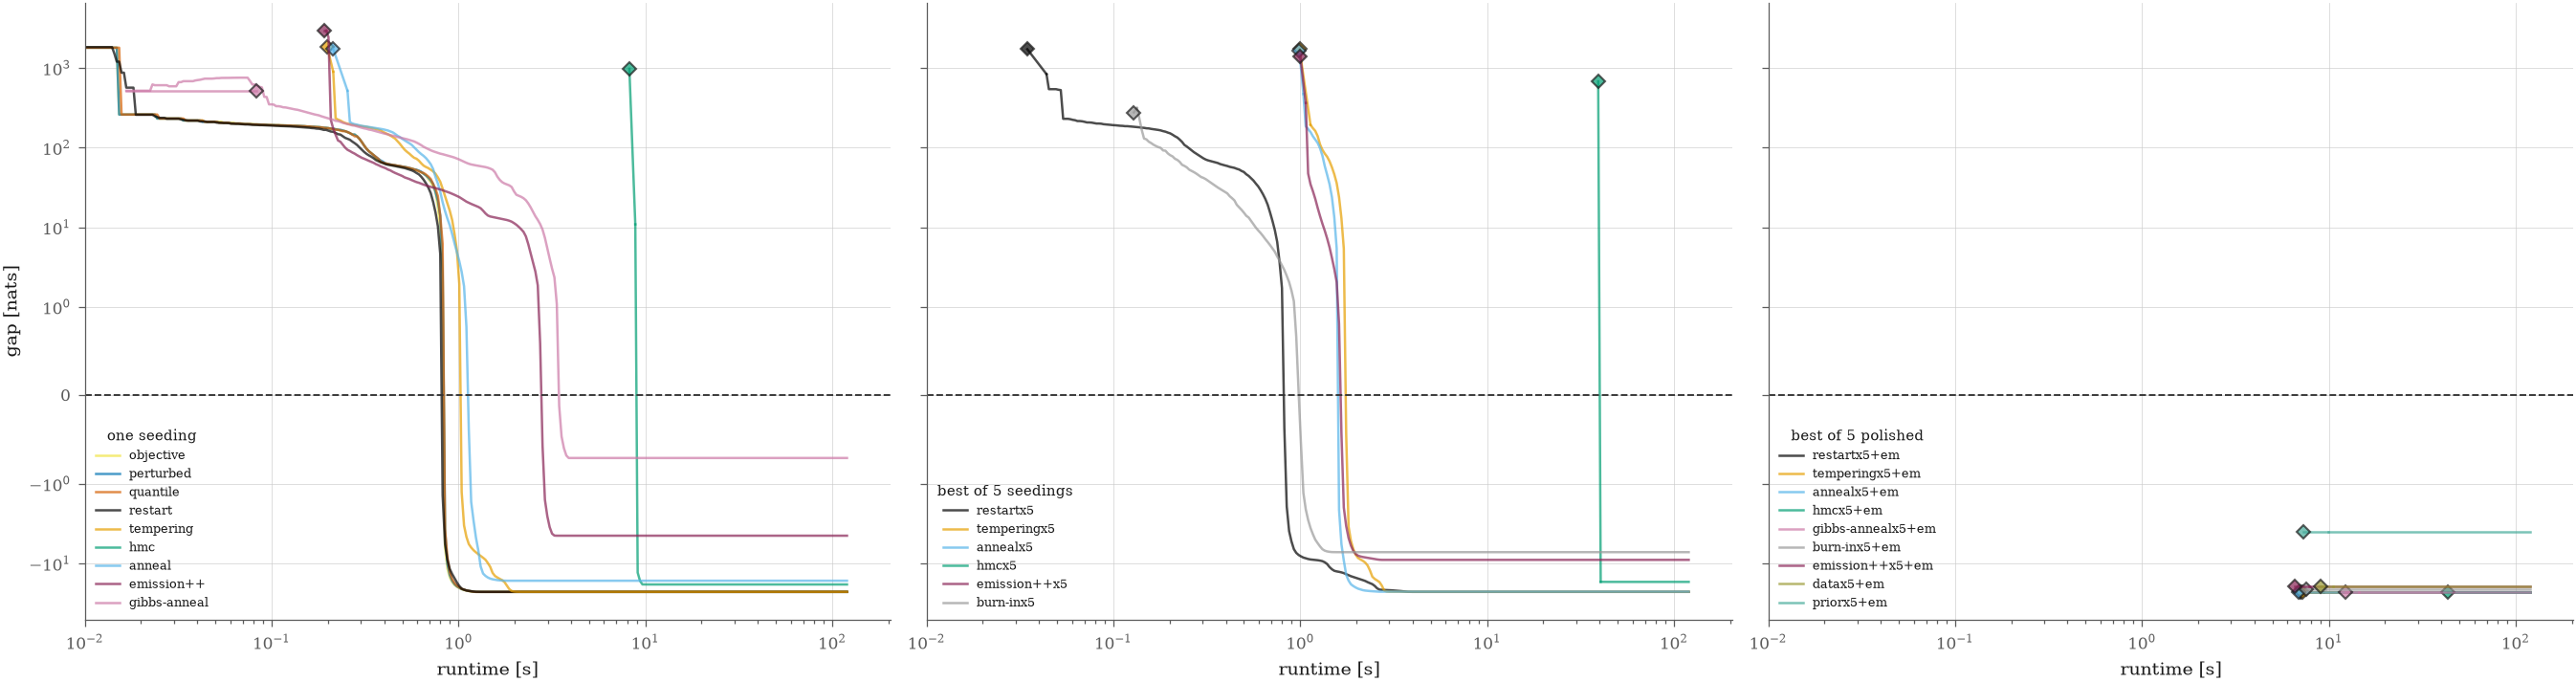

In [8]:
#: The log-spaced grid of seconds every trial is read on: from under the
#: fastest handover to the budget.
GRID = np.geomspace(1e-3, BUDGET.size, 400)

#: Draw each start's ±1 standard-deviation band; off by default, since with
#: every start on the axes the bands hide the curves.
SHOW_BANDS = False

#: The cut: a start whose mean final gap is at most this many nats ends
#: within a nat of the generating parameters or past them.
WITHIN = 1.0

# Each start's mean final gap, read where its polishes stopped.
final = {row.start: float(np.mean(row.gap)) for row in rows}
# Each start's band on the grid.
bands = {name: gap_band(trials[name], REFERENCE, GRID) for name in ORDER}
# Per panel, the starts that end within a nat of the generating parameters
# or past them, best first; the rest are read in the tables above. A best-of
# start takes its base start's colour, so a start and its best of five read
# as one colour across the two panels.
competitive = sorted((n for n in ORDER if final[n] <= WITHIN), key=final.__getitem__)
panels = {
    "one seeding": [n for n in competitive if n in STARTS],
    f"best of {BEST_OF} seedings": [n for n in competitive if n in BEST_OF_STARTS],
    f"best of {BEST_OF} polished": [n for n in competitive if n in BEST_OF_EM_STARTS],
}
groups = {**BEST_OF_STARTS, **BEST_OF_EM_STARTS}
base = {n: groups[n].name if n in groups else n for n in competitive}
bases = list(dict.fromkeys(base[n] for n in competitive))
colours = start_styles(bases)
with notebook_style():
    figure = gap_panels(
        {heading: {n: bands[n] for n in names} for heading, names in panels.items()},
        {heading: final for heading in panels},
        {n: colours[base[n]] for n in competitive},
        ylabel="gap [nats]",
        show_bands=SHOW_BANDS,
    )
    plt.show()

## Read beside experiments 009 and 010

Experiment 009 compared nine of these starts on the key coupled model in
projection, 100 components over 4,000 observations, and had `emission++`
reaching the best projected value on all six of its instances; experiment 010
measured the Gaussian-mixture EM start as a control. What this draw says over
five seeds, the handover from the compared table and the rest from the
`host-dependent` one, as it read on the 4-core host:

**Polished to its tolerance, the surrogate's seeding passes the reference on
every seed.** `objective`, `perturbed`, `quantile`, `restart` and `tempering`
end 22.8 nats above the generating parameters, `restart` and `tempering` with a
spread of 0.1 and 0.2 over the seeds; `hmc` ends 18.4 ± 5.9 above and `anneal`
16.5 ± 8.5. Under the six passes this notebook held before issue #898, the same
starts ended 199 to 203 nats below the reference: the order at six passes was
the order of how fast a start converges, not of where it ends.

**The rules over the pairs end where their seed puts them.** `data` ends 35.3
± 17.3 nats below, `kmeans++` 23.6 ± 17.5 and `gaussian-em` 19.2 ± 2.6;
`emission++`, experiment 009's winner, spans the most, 4.5 ± 18.6 above. `prior`
ends 51.1 ± 82.1 below, one of its five fits stopped where EM emptied a
component. Five seeds are a spread and not a ranking, and #559 keeps the
defaults.

**Where a start begins does not say where it ends.** `gibbs-anneal` hands over
the smallest gap, 518.1 ± 169.4 nats, and `burn-in` the next, 545.0 ± 268.0;
they end 0.7 ± 21.6 above and 21.6 ± 22.8 below. The surrogate starts hand
over 1,797.0 nats short and end first.

**Annealing on the likelihood itself does not beat annealing on the
surrogate.** `gibbs-anneal`, issue #901's heat bath over the assignments, reads
the count-pair likelihood at every sweep and hands over 1,210.6 nats nearer
than `anneal` does; polished, it ends 15.8 nats below `anneal` and 22.1 below
the surrogate starts, and takes the most iterations, 344 ± 48.

**Five seedings scored at the handover help some starts and not others.**
Each seeding draws from its own generator spawned from the cell's (issue #912).
The best of five moves `data` from 35.3 ± 17.3 nats below the reference to
5.2 ± 15.9 below, `kmeans++` from 23.6 to 11.8 ± 8.0 below and `burn-in` from
21.6 below to 7.2 ± 17.3 above; `anneal` reaches the surrogate starts' 22.7 ±
0.2 above. `prior` does not improve, 57.4 ± 56.4 below, and `gibbs-anneal`
falls from 0.7 above to 8.4 ± 22.7 below: the seeding of highest likelihood at
equal weights is not the one EM ends best from.

**Polishing every seeding and keeping the best fit is what closes the gap.**
With `Selection.POLISHED`, `restart`, `hmc`, `anneal`, `gibbs-anneal` and
`tempering` end 22.8 to 22.9 nats above the reference with a spread of at
most 0.1 over the seeds, `gibbs-anneal` from 8.4 below under the handover's
selection; `burn-in` ends 20.9 ± 4.1 above, `data` and `emission++` 19.7 ± 6.9
and `prior` 4.0 ± 5.9. `kmeans++` does not move, 11.8 ± 8.0 below: its seeding
of highest likelihood is also the one EM ends best from. The cost is five
polishes a cell, 5.4 to 12.3 s against 1.1 to 3.1 s.

**The polish spends the budget, not the start.** Every single-seeding start
hands over within 9 s --- the warmed-up `hmc` at 8.2 s, its 300 warm-up
proposals the most of it --- and every cell stops at its tolerance or an
emptied component inside its 120 s. Five seedings multiply a start's own
cost: `hmc`'s best of five hands over at 39.3 s, and polished throughout it
is the longest cell of the notebook at 43.3 s. The polish's iterations are about 0.012 s each, against
0.11 s before the count M step moved to the compiled kernel (issue #922). The
passes column is the cost that transfers between hosts.

## Further work

- The seedings are read on the emission model alone; none is yet read through
  the coupled fit with its lattice and chains: issue #555.
- Spectral seeding by moment inversion, the sixth candidate of #541, is not
  among the starts because no implementation exists: issue #554.
- Nothing here moves a default; the ordering is read beside experiment 009's
  and not tested against it: issue #559.
- The count-pair coupled instance has no notebook of its own, and this one is
  the seventh of the eighteen catalogue rows: issue #682.